In [1]:
# 1. Import Library
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

In [2]:
# 2. Import Function
sys.path.append(os.path.abspath("../.."))

from src.data_preparation import (
    remove_duplicates,
    remove_same_ohlc_rows
)

In [3]:
# 3. Load Parameter
with open("../../config/parameter.yaml", "r") as f:
    parameter_config = yaml.safe_load(f)

columns_parameter = parameter_config["columns_parameter"]

raw_to_drop = columns_parameter["raw_to_drop"]
columns_to_drop = columns_parameter["columns_to_drop"]

all_columns_to_drop = raw_to_drop + columns_to_drop

print(f"raw_to_drop     : {raw_to_drop}")
print(f"columns_to_drop : {columns_to_drop}")

raw_to_drop     : ['open', 'high', 'low', 'close', 'adj_close', 'volume']
columns_to_drop : ['close_vwap_21_ratio', 'z_score_return_21', 'volume_spike_ratio', 'bb_pct_b', 'z_score_gk_var_21_rank_pct']


In [4]:
# 4. Load Data
with open("../../config/paths.yaml", "r") as f:
    paths_config = yaml.safe_load(f)

preparation_data_path = paths_config["data"]["05_data_preparation"]

csv_file_path_train = os.path.join(preparation_data_path, "01_train_prep_technicals.csv")
csv_file_path_val = os.path.join(preparation_data_path, "02_val_prep_technicals.csv")
csv_file_path_test = os.path.join(preparation_data_path, "03_test_prep_technicals.csv")

df_data_train = pd.read_csv(csv_file_path_train, parse_dates=["date"])
df_data_val = pd.read_csv(csv_file_path_val, parse_dates=["date"])
df_data_test = pd.read_csv(csv_file_path_test, parse_dates=["date"])
df_data_train_ready = pd.concat([df_data_train, df_data_val], ignore_index=True)
df_data_train_ready = df_data_train_ready.sort_values(by=['ticker', 'date']).reset_index(drop=True)
df_data_train_ready = remove_duplicates(df_data_train_ready)
df_data_train_ready = remove_same_ohlc_rows(df_data_train_ready)

df_data_train.drop(columns=all_columns_to_drop, inplace=True)
df_data_val.drop(columns=all_columns_to_drop, inplace=True)
df_data_test.drop(columns=all_columns_to_drop, inplace=True)
df_data_train_ready.drop(columns=all_columns_to_drop, inplace=True)

print("df_data_train shape       :", df_data_train.shape)
print("df_data_val shape         :", df_data_val.shape)
print("df_data_test shape        :", df_data_test.shape)
print("df_data_train_ready shape :", df_data_train_ready.shape)

df_data_train shape       : (67853, 39)
df_data_val shape         : (18420, 39)
df_data_test shape        : (18657, 39)
df_data_train_ready shape : (86000, 39)


In [5]:
# 5. Splitting Features & Label
target = "rank_pct"

feature_cols = df_data_train_ready.select_dtypes(include=[np.number]).columns.tolist()
if target in feature_cols:
    feature_cols.remove(target)

X_train = df_data_train_ready[feature_cols]
y_train = df_data_train_ready[target]

X_test = df_data_test[feature_cols]
y_test = df_data_test[target]

print("Total features :", len(feature_cols))

Total features : 36


In [6]:
# 6. Hyperparameter Tuning
param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 5, 6, 8, 10],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0, 0.1, 0.5, 1.0]
}

model_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=model_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameter :")
print(random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameter :
{'subsample': 0.7, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}


In [7]:
# 7. Train Model
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [8]:
# 8. Model Evaluation
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

df_eval = pd.DataFrame({"Actual": y_test, "Predicted": y_pred}).reset_index(drop=True)

MAE  : 0.247715
RMSE : 0.286963
R²   : 0.010186


In [9]:
# ------ Information Coefficient (IC) ------
ic_pearson, p_value_p = pearsonr(df_eval["Predicted"], df_eval["Actual"])
ic_spearman, p_value_s = spearmanr(df_eval["Predicted"], df_eval["Actual"])

print(f"Pearson IC (Linear) : {ic_pearson:.6f}")
print(f"Spearman IC (Rank)  : {ic_spearman:.6f}")

Pearson IC (Linear) : 0.101769
Spearman IC (Rank)  : 0.095132


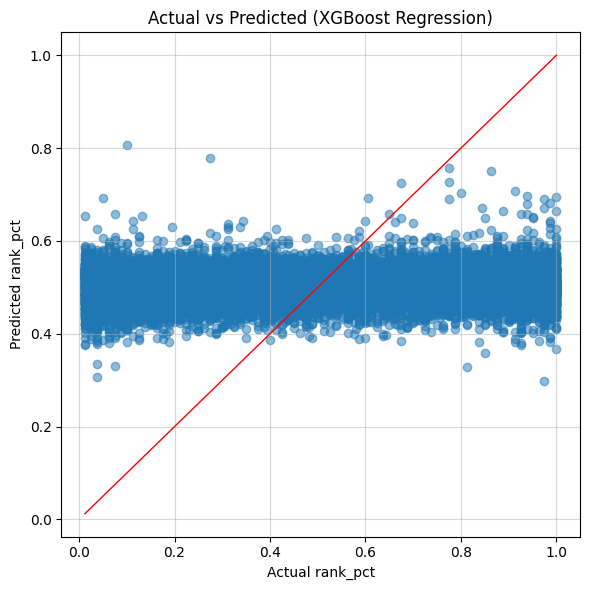

In [10]:
# ------ Scatter Plot ------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=1)
plt.title("Actual vs Predicted (XGBoost Regression)")
plt.xlabel("Actual rank_pct")
plt.ylabel("Predicted rank_pct")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

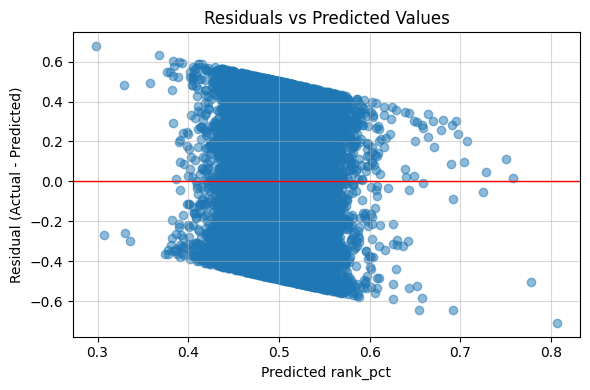

In [11]:
# ------ Residual Plot ------
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', lw=1)
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted rank_pct")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
# ------ Features Importances ------
importance = best_model.feature_importances_
fi = pd.Series(importance, index=feature_cols).sort_values(ascending=False)

df_feature_importance = fi.reset_index()
df_feature_importance.columns = ["Feature", "Importance"]

print(df_feature_importance)

                    Feature  Importance
0            current_return    0.034342
1               cmf_5_delta    0.034277
2               ema_9_ratio    0.033245
3             rsi_14_regime    0.030289
4   close_highest_200_ratio    0.029940
5             ema_200_ratio    0.029926
6              ema_21_ratio    0.029678
7              ema_50_ratio    0.029306
8        current_volatility    0.029249
9                     cmf_5    0.028940
10    rolling_std_return_21    0.028912
11        z_score_gk_var_21    0.028649
12   close_highest_50_ratio    0.028368
13           z_score_atr_14    0.028196
14                   regime    0.027852
15        z_score_volume_21    0.027711
16             lag_return_1    0.027641
17     macd_hist_norm_close    0.027498
18             lag_return_5    0.027171
19         lag_volatility_1    0.027081
20     money_flow_magnitude    0.027068
21        rsi_sma_14_regime    0.026909
22         lag_volatility_2    0.026760
23          rolling_kurt_21    0.026661


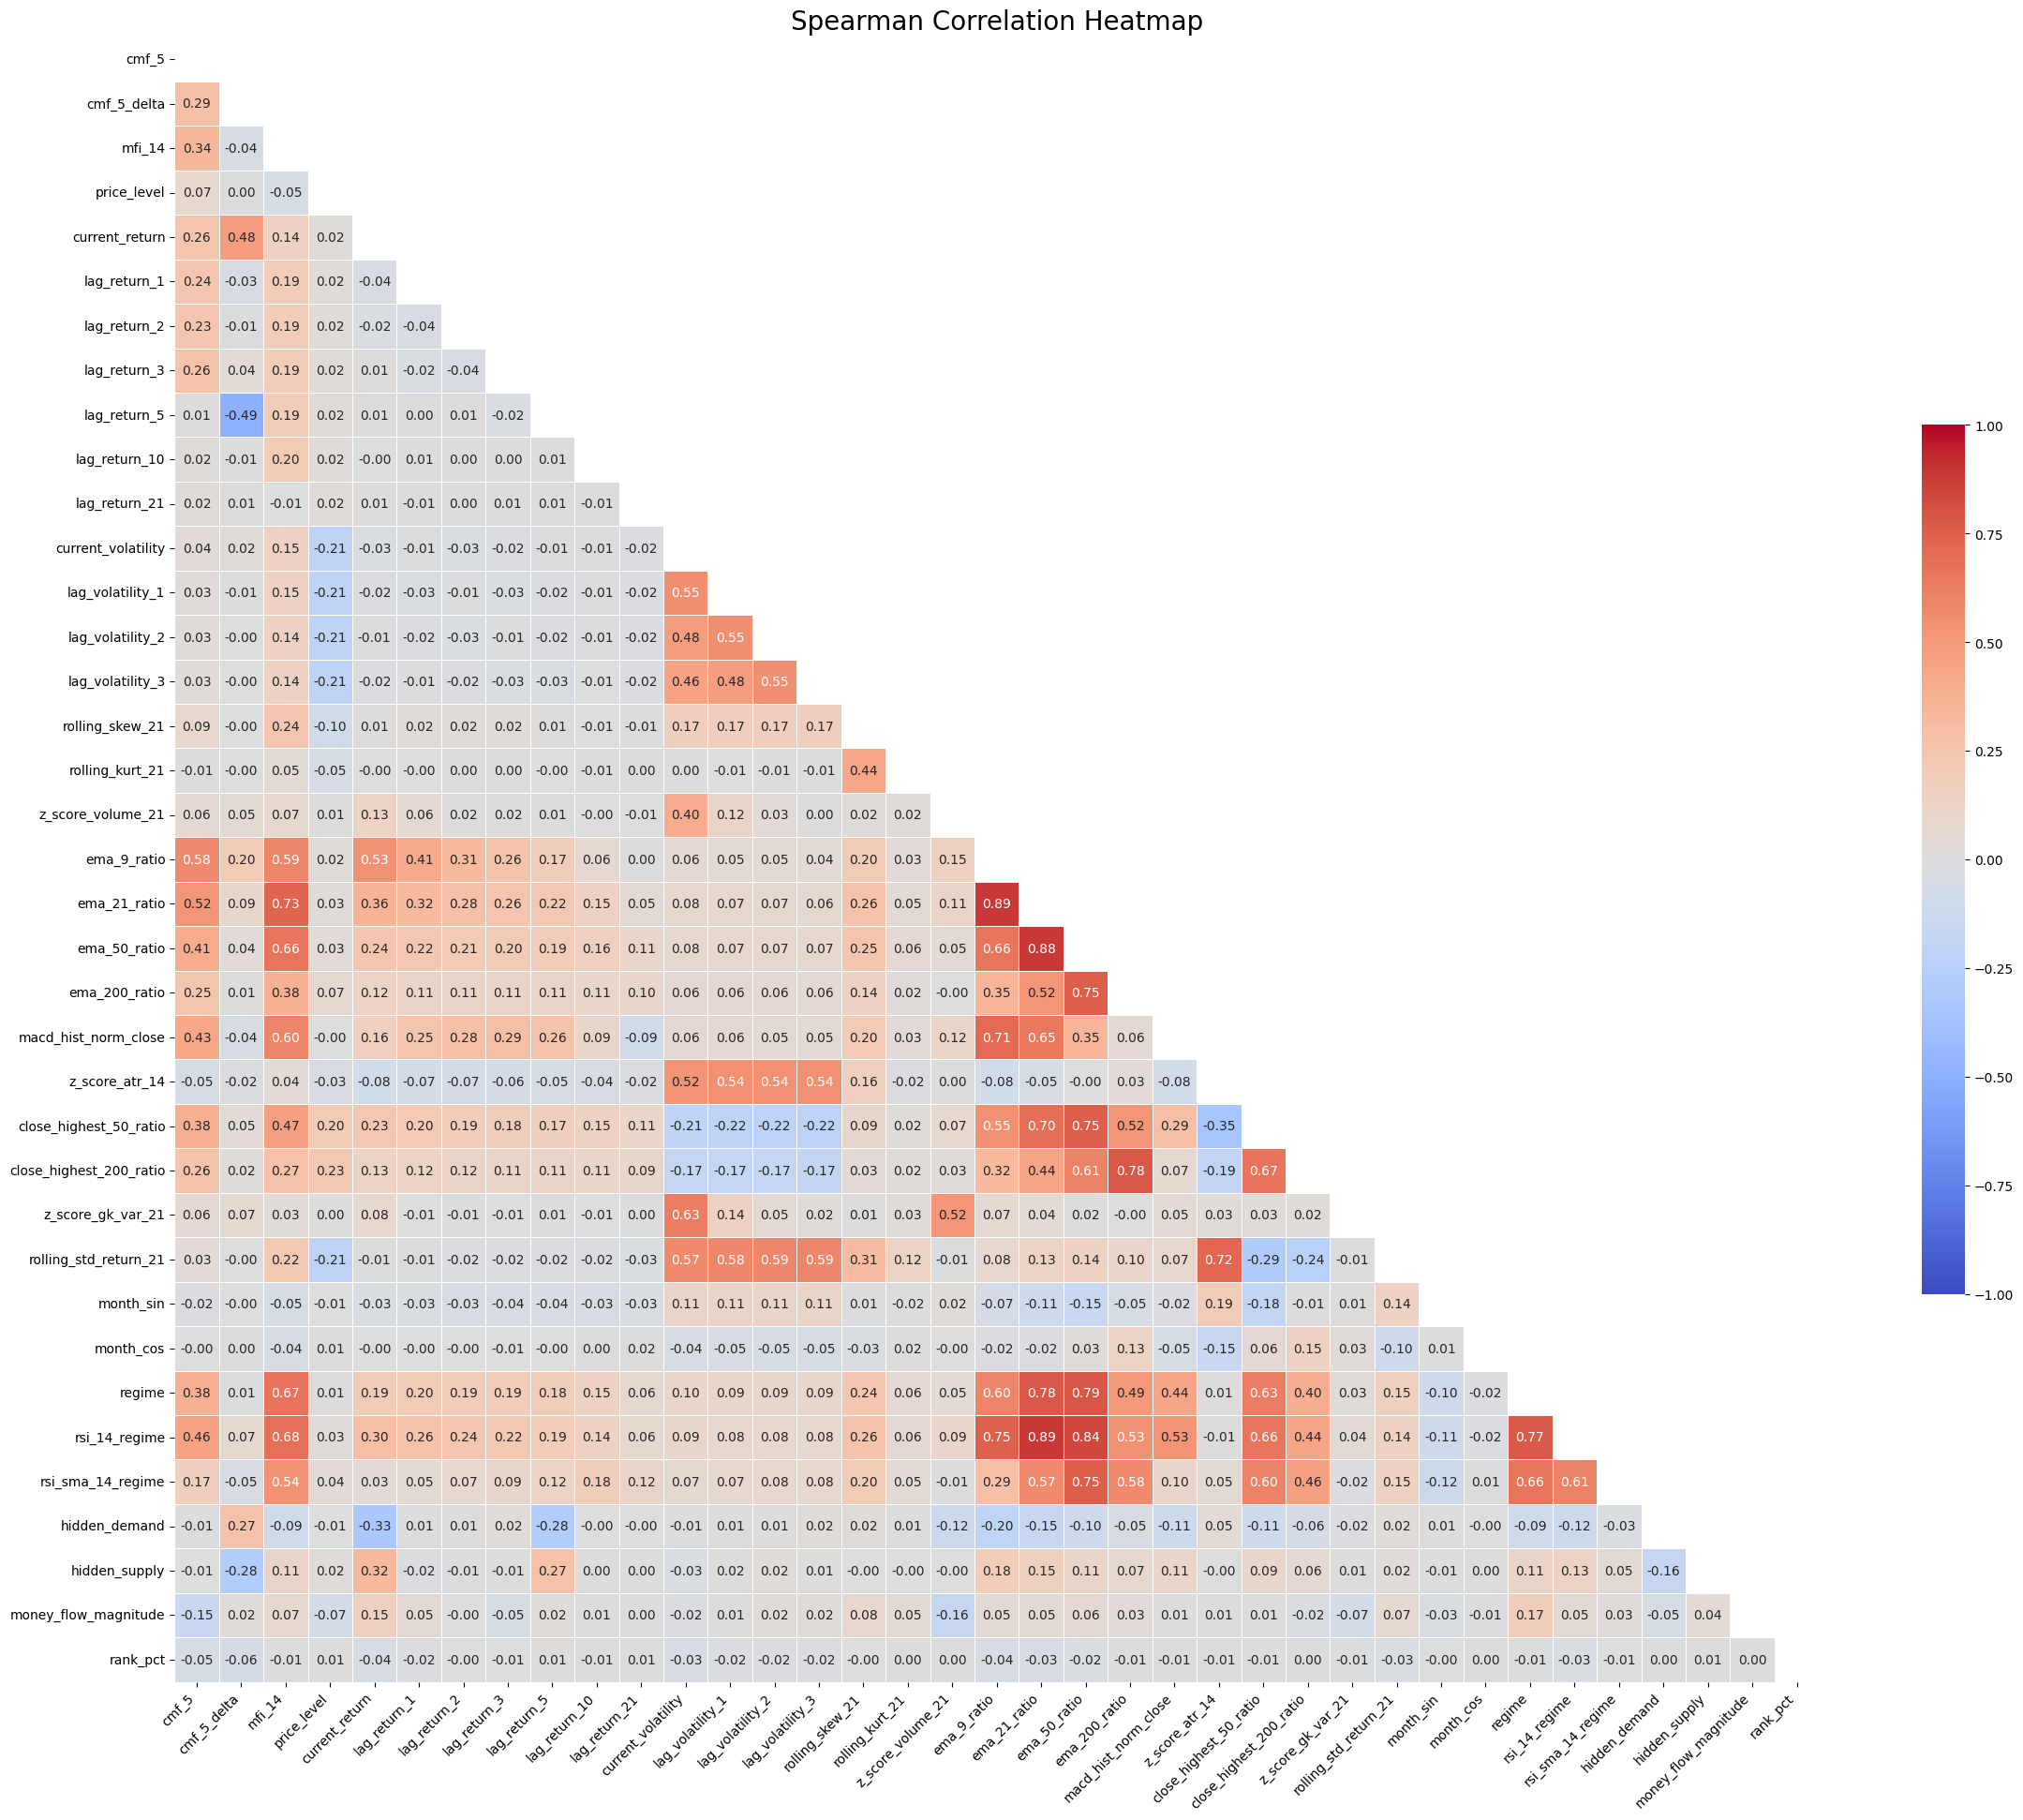

In [13]:
# ------ Spearman Correlation Heatmap ------
numeric_features = df_data_train.select_dtypes(include=[np.number])
corr_matrix = numeric_features.corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(24, 20))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, 
    vmax=1, 
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .5}
)

plt.title('Spearman Correlation Heatmap', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# ------ Identify Highly Correlated Features ------
threshold = 0.90
upper = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant_pairs = []

for column in upper.columns:
    for index in upper.index:
        if upper.loc[index, column] > threshold:
            redundant_pairs.append(f"{upper.loc[index, column]:.6f} : {index} <---> {column}")

print("Correlation :")
if not redundant_pairs:
    print(f"No features have a correlation above {threshold}")
else:
    for pair in redundant_pairs:
        print(pair)

Correlation :
No features have a correlation above 0.9
